Dataset Loaded Successfully!

Shape of Dataset:
(9551, 21)

Columns:
Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

Data Types:
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
P

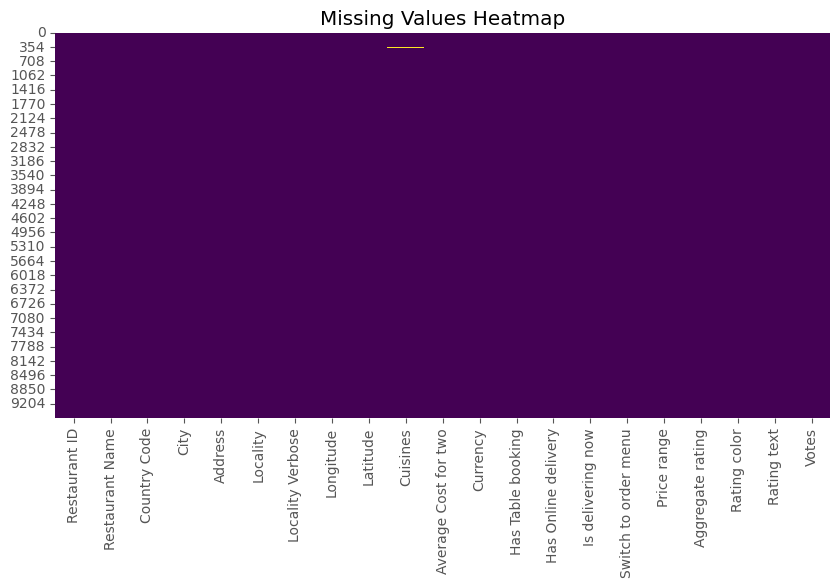


Duplicate Records: 0

Numerical Summary:
       Restaurant ID  Country Code    Longitude     Latitude  \
count   9.551000e+03   9551.000000  9551.000000  9551.000000   
mean    9.051128e+06     18.365616    64.126574    25.854381   
std     8.791521e+06     56.750546    41.467058    11.007935   
min     5.300000e+01      1.000000  -157.948486   -41.330428   
25%     3.019625e+05      1.000000    77.081343    28.478713   
50%     6.004089e+06      1.000000    77.191964    28.570469   
75%     1.835229e+07      1.000000    77.282006    28.642758   
max     1.850065e+07    216.000000   174.832089    55.976980   

       Average Cost for two  Price range  Aggregate rating         Votes  
count           9551.000000  9551.000000       9551.000000   9551.000000  
mean            1199.210763     1.804837          2.666370    156.909748  
std            16121.183073     0.905609          1.516378    430.169145  
min                0.000000     1.000000          0.000000      0.000000  
25%   

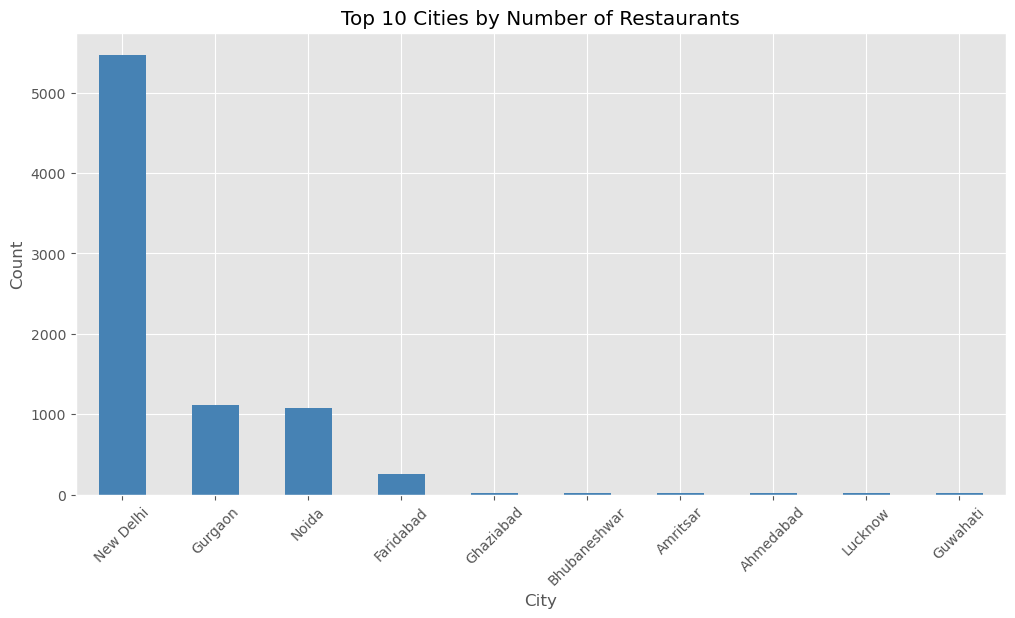

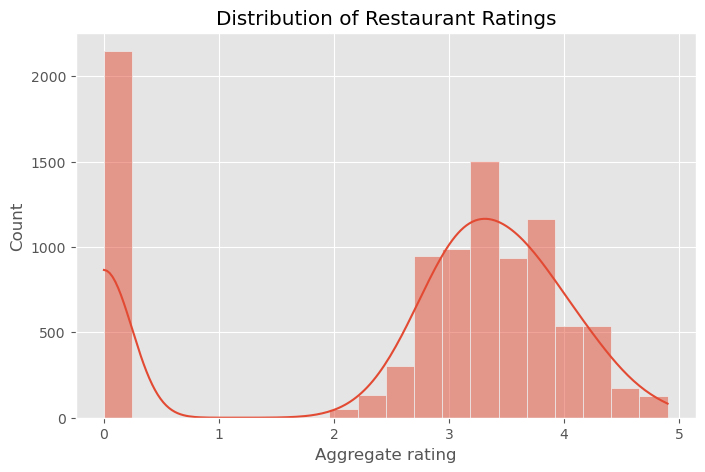

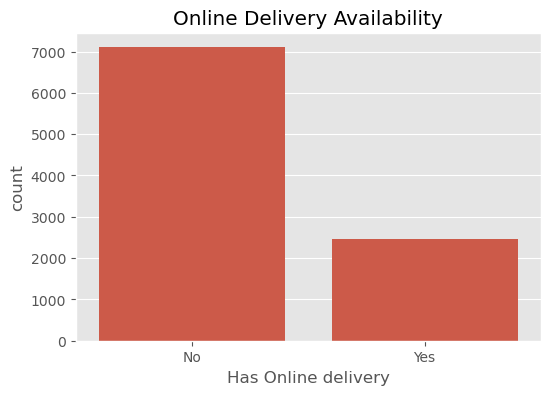

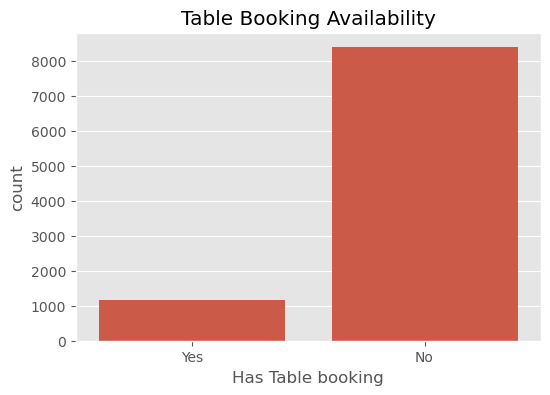

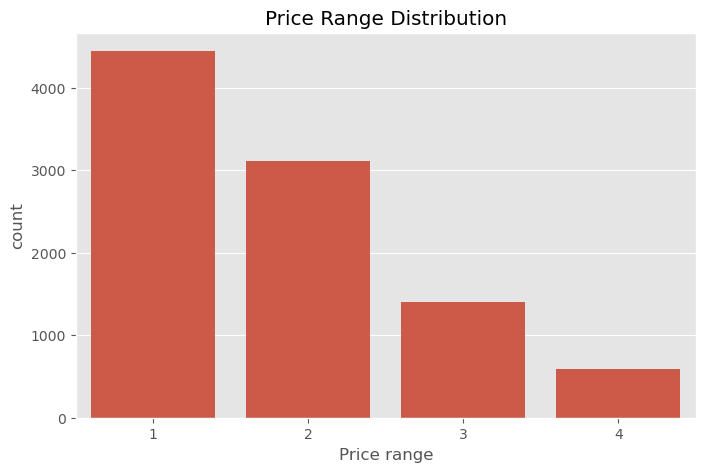

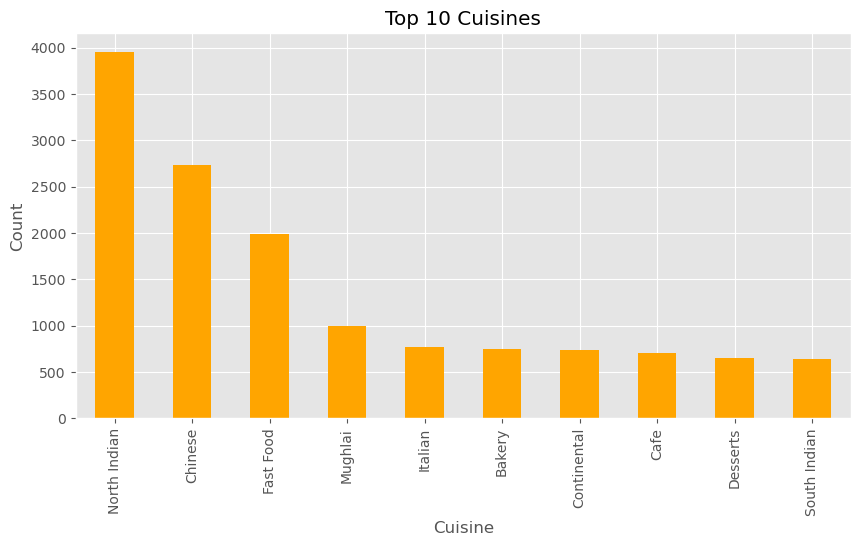

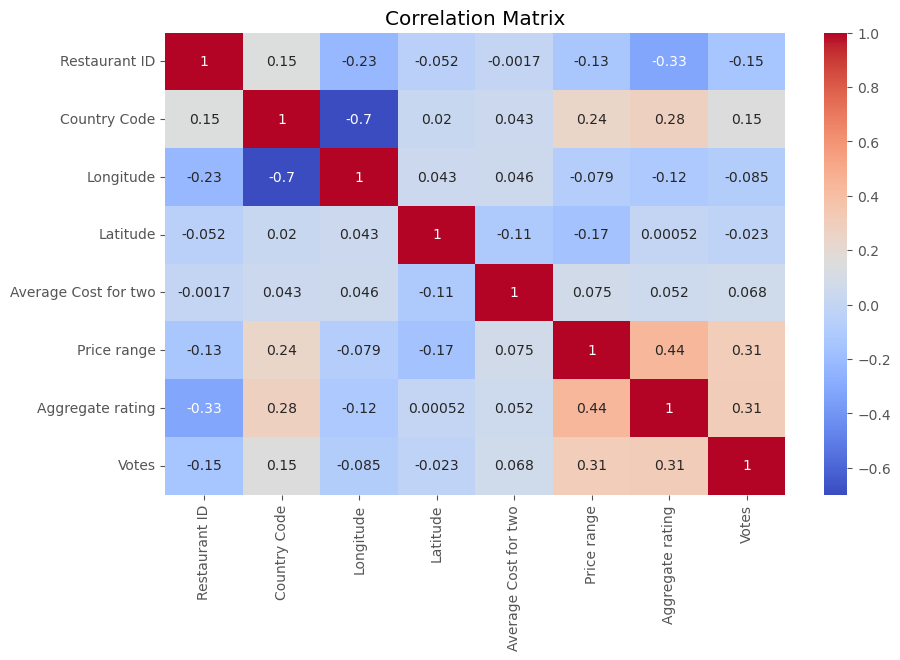

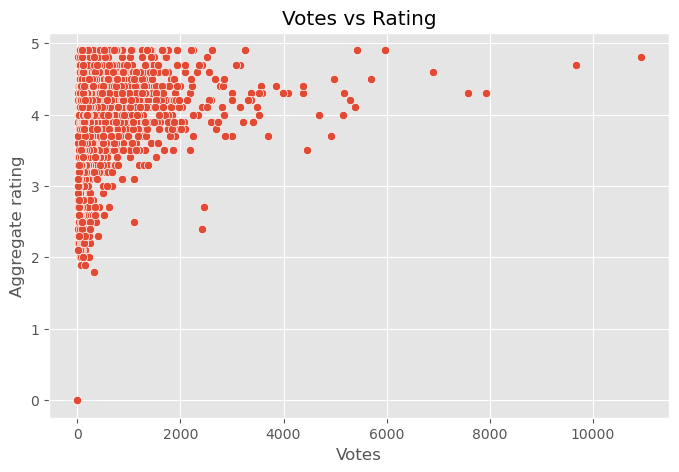

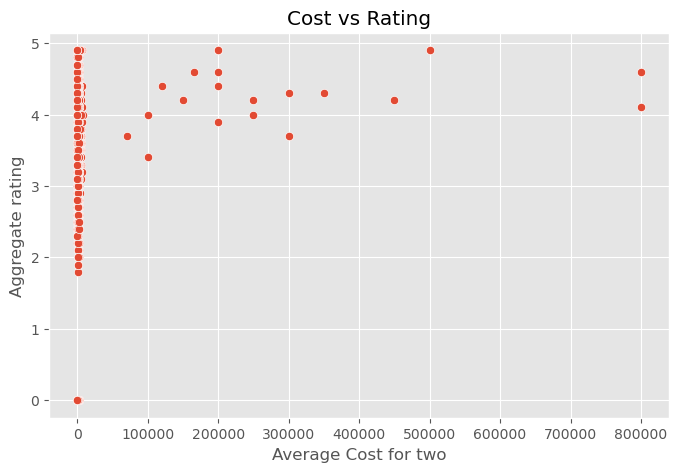

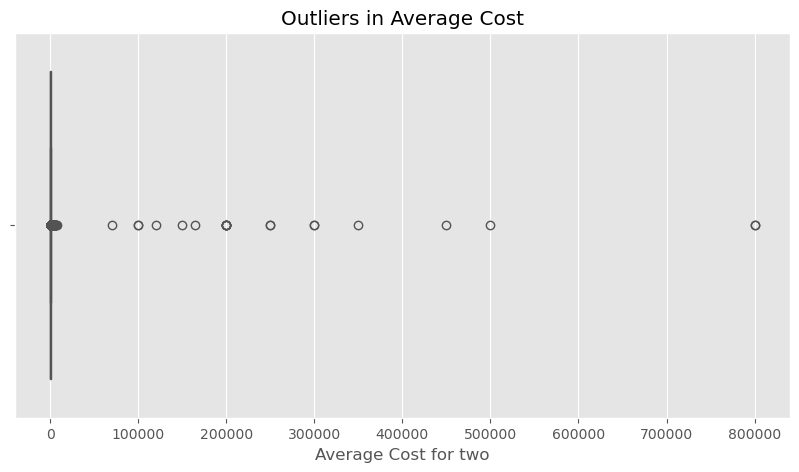

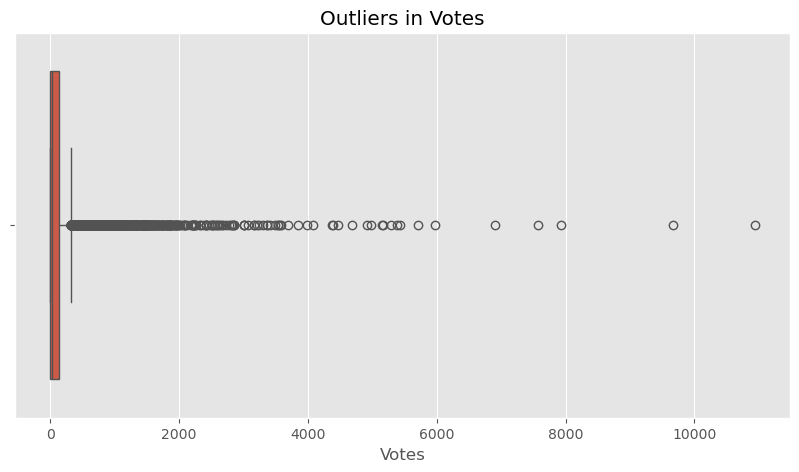

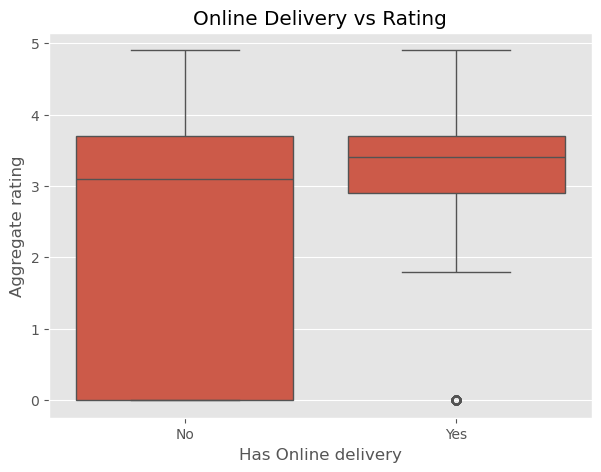

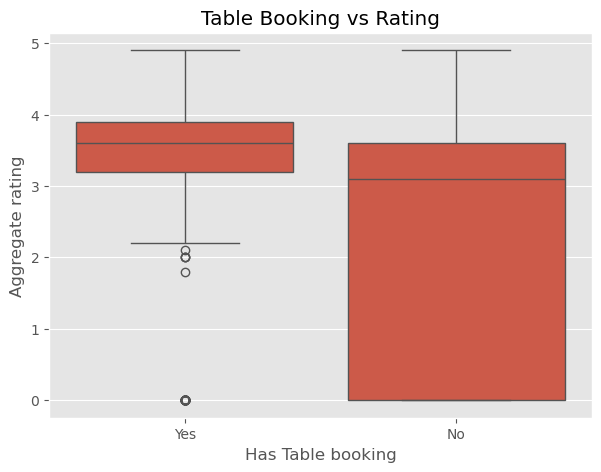

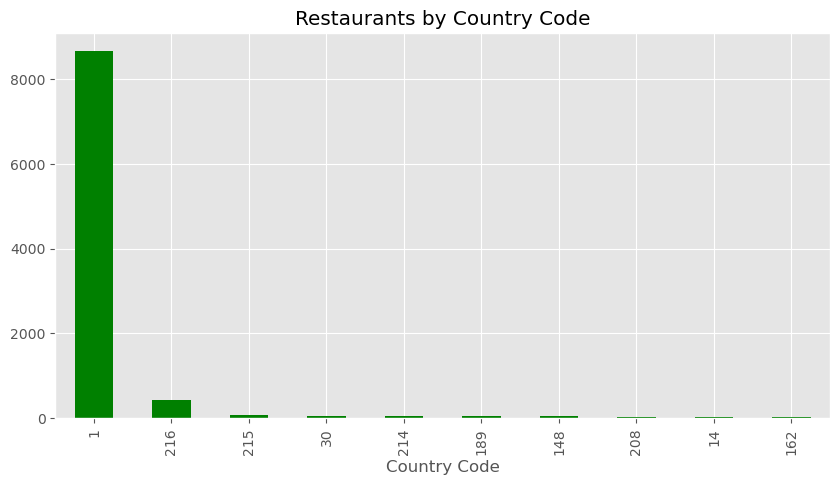


========== EDA REPORT ==========
Total Restaurants: 9551
Total Cities: 141
Highest Rated Restaurant:
Restaurant Name                 Ooma
City                Mandaluyong City
Aggregate rating                 4.9
Name: 3, dtype: object

Most Common City:
New Delhi

Most Common Cuisine:
North Indian

Average Rating:
2.67

Average Cost for Two:
1199.21

Most Votes Received:
10934

EDA Completed Successfully!


In [ ]:
# ==========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

# ------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------

df = pd.read_csv(r"C:\Users\Shaik Farooq\OneDrive\Documents\Desktop\vehicalperformance\dataset1.csv")

print("Dataset Loaded Successfully!\n")

# ------------------------------------------
# 2. BASIC INFORMATION
# ------------------------------------------

print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
print(df.head())

# ------------------------------------------
# 3. MISSING VALUES
# ------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# ------------------------------------------
# 4. DUPLICATE VALUES
# ------------------------------------------

duplicates = df.duplicated().sum()

print("\nDuplicate Records:", duplicates)

# ------------------------------------------
# 5. STATISTICAL SUMMARY
# ------------------------------------------

print("\nNumerical Summary:")
print(df.describe())

print("\nCategorical Summary:")
print(df.describe(include='object'))

# ------------------------------------------
# 6. TOP 10 CITIES WITH MOST RESTAURANTS
# ------------------------------------------

plt.figure(figsize=(12,6))

df['City'].value_counts().head(10).plot(
    kind='bar',
    color='steelblue'
)

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# ------------------------------------------
# 7. RATING DISTRIBUTION
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(
    df['Aggregate rating'],
    bins=20,
    kde=True
)

plt.title("Distribution of Restaurant Ratings")
plt.show()

# ------------------------------------------
# 8. ONLINE DELIVERY ANALYSIS
# ------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(
    x='Has Online delivery',
    data=df
)

plt.title("Online Delivery Availability")
plt.show()

# ------------------------------------------
# 9. TABLE BOOKING ANALYSIS
# ------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(
    x='Has Table booking',
    data=df
)

plt.title("Table Booking Availability")
plt.show()

# ------------------------------------------
# 10. PRICE RANGE ANALYSIS
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    x='Price range',
    data=df
)

plt.title("Price Range Distribution")
plt.show()

# ------------------------------------------
# 11. TOP CUISINES
# ------------------------------------------

top_cuisines = (
    df['Cuisines']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

top_cuisines.plot(
    kind='bar',
    color='orange'
)

plt.title("Top 10 Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Count")
plt.show()

# ------------------------------------------
# 12. CORRELATION ANALYSIS
# ------------------------------------------

numeric_cols = df.select_dtypes(
    include=['int64','float64']
)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# ------------------------------------------
# 13. RATING VS VOTES
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Votes',
    y='Aggregate rating',
    data=df
)

plt.title("Votes vs Rating")
plt.show()

# ------------------------------------------
# 14. AVERAGE COST VS RATING
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Average Cost for two',
    y='Aggregate rating',
    data=df
)

plt.title("Cost vs Rating")
plt.show()

# ------------------------------------------
# 15. OUTLIER DETECTION
# ------------------------------------------

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Average Cost for two']
)

plt.title("Outliers in Average Cost")
plt.show()

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Votes']
)

plt.title("Outliers in Votes")
plt.show()

# ------------------------------------------
# 16. ONLINE DELIVERY VS RATING
# ------------------------------------------

plt.figure(figsize=(7,5))

sns.boxplot(
    x='Has Online delivery',
    y='Aggregate rating',
    data=df
)

plt.title("Online Delivery vs Rating")
plt.show()

# ------------------------------------------
# 17. TABLE BOOKING VS RATING
# ------------------------------------------

plt.figure(figsize=(7,5))

sns.boxplot(
    x='Has Table booking',
    y='Aggregate rating',
    data=df
)

plt.title("Table Booking vs Rating")
plt.show()

# ------------------------------------------
# 18. COUNTRY ANALYSIS
# ------------------------------------------

country_counts = df['Country Code'].value_counts().head(10)

plt.figure(figsize=(10,5))

country_counts.plot(
    kind='bar',
    color='green'
)

plt.title("Restaurants by Country Code")
plt.show()

# ------------------------------------------
# 19. INSIGHTS REPORT
# ------------------------------------------

print("\n========== EDA REPORT ==========")

print(f"Total Restaurants: {len(df)}")

print(f"Total Cities: {df['City'].nunique()}")

print(f"Highest Rated Restaurant:")
print(
    df.loc[
        df['Aggregate rating'].idxmax(),
        ['Restaurant Name','City','Aggregate rating']
    ]
)

print("\nMost Common City:")
print(df['City'].mode()[0])

print("\nMost Common Cuisine:")
print(top_cuisines.index[0])

print("\nAverage Rating:")
print(round(df['Aggregate rating'].mean(),2))

print("\nAverage Cost for Two:")
print(round(df['Average Cost for two'].mean(),2))

print("\nMost Votes Received:")
print(df['Votes'].max())

print("\nEDA Completed Successfully!")